Section import

Ce code importe des bibliothèques utilisées pour créer et entraîner un modèle de réseau de neurones pour les images. Certaines bibliothèques servent à construire le modèle et ses couches, d’autres à préparer les images et à afficher des graphiques. À la fin, le code connecte Google Drive à Google Colab pour pouvoir utiliser les fichiers et les données qui sont stockés dans le Drive.

In [11]:
import os
from keras import backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Input, Dropout
from keras.layers import Activation, Flatten, Dense
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Section paramètres

Ce code prépare les paramètres nécessaires pour entraîner un modèle d’images : il définit le dossier des données, la taille des images, le nombre d’images d’entraînement et de test, le nombre d’époques et la taille des lots. Il précise aussi la forme des images en entrée du modèle selon la configuration de Keras

In [2]:
os.chdir("/content/drive/MyDrive/v_data")
img_width, img_height = 224, 224
train_data_dir = 'v_data/train'
validation_data_dir = 'v_data/test'
nb_train_samples = 400
nb_validation_samples = 100
epochs = 15
batch_size = 16
num_filters = 8
filter_size = 3
if K.image_data_format() == 'channels_first':input_shape = (3, img_width, img_height)
else:input_shape = (img_width, img_height, 3)

Section transformation données

Ce code prépare et charge les images d’entraînement et de test, applique quelques transformations aux images pour améliorer l’apprentissage, puis les organise en lots (batch) pour les utiliser dans l’entraînement et la validation du modèle.

In [3]:
train_datagen = ImageDataGenerator(
rescale = 1. / 255,
shear_range = 0.2,
zoom_range = 0.2,
horizontal_flip = True)
test_datagen = ImageDataGenerator(rescale = 1. / 255)
train_generator = train_datagen.flow_from_directory(train_data_dir,target_size =(img_width, img_height),
batch_size = batch_size, class_mode ='categorical')
validation_generator = test_datagen.flow_from_directory(validation_data_dir,target_size =(img_width, img_height),batch_size = batch_size, class_mode ='categorical')

Found 400 images belonging to 2 classes.
Found 100 images belonging to 2 classes.


Section architecture du CNN

Ce code crée un modèle de réseau de neurones avec Sequential, qui permet d’ajouter les couches une par une dans un ordre simple. Le modèle contient une couche de convolution pour extraire les caractéristiques des images, une activation ReLU, puis MaxPooling pour réduire la taille des données. Ensuite Flatten transforme les données en vecteur et les couches Dense réalisent la classification finale. Enfin, model.summary() affiche le résumé du modèle.

In [4]:
model = Sequential()
model.add(Conv2D(num_filters, (3,3), input_shape = input_shape))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size = (2, 2)))
model.add(Flatten())
model.add(Dense(24))
model.add(Dense(2))
model.add(Activation('sigmoid'))
print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 222, 222, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 98568)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24)             │     2,365,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 2)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,365,930 (9.03 MB)

 Trainable params: 2,365,930 (9.03 MB)

 Non-trainable params: 0 (0.00 B)

None


Section entrainement du modèle et évaluation

Ce code prépare et entraîne le modèle./ model.compile définit la fonction de perte (binary_crossentropy), l’optimiseur (rmsprop) et la métrique à suivre (accuracy)./model.fit lance l’entraînement avec les images chargées par les générateurs, en précisant le nombre d’étapes par époque, le nombre d’époques, et les données de validation pour évaluer la performance du modèle à chaque époque.

In [5]:
model.compile(loss ='binary_crossentropy',
optimizer ='rmsprop',

metrics =['accuracy'])
history=model.fit(train_generator,
steps_per_epoch = nb_train_samples // batch_size,
epochs = epochs, validation_data = validation_generator,
validation_steps = nb_validation_samples // batch_size)

Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 359s 14s/step - accuracy: 0.6150 - loss: 4.6047 - val_accuracy: 0.6146 - val_loss: 0.9982
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 206ms/step - accuracy: 0.7150 - loss: 0.7630 - val_accuracy: 0.7812 - val_loss: 0.5009
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 293ms/step - accuracy: 0.7925 - loss: 0.5172 - val_accuracy: 0.6979 - val_loss: 0.6863
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 204ms/step - accuracy: 0.8200 - loss: 0.5283 - val_accuracy: 0.7396 - val_loss: 0.5266
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 228ms/step - accuracy: 0.8175 - loss: 0.4374 - val_accuracy: 0.8438 - val_loss: 0.4472
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 248ms/step - accuracy: 0.8275 - loss: 0.4033 - val_accuracy: 0.8333 - val_loss: 0.3614
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 213ms/step - accuracy: 0.8575 - loss: 0.3743 - val_accuracy: 0.8229 - val_loss: 0.3820
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 288ms/step - accuracy: 0.8675 - loss: 0.3512 - val_accuracy: 0.

Section visualisation

Ce code affiche des graphiques pour suivre l’entraînement du modèle.Le premier graphique montre l’évolution de l’accuracy sur les données d’entraînement et de validation à chaque époque.Le second graphique montre l’évolution de la loss (erreur) sur les mêmes données.

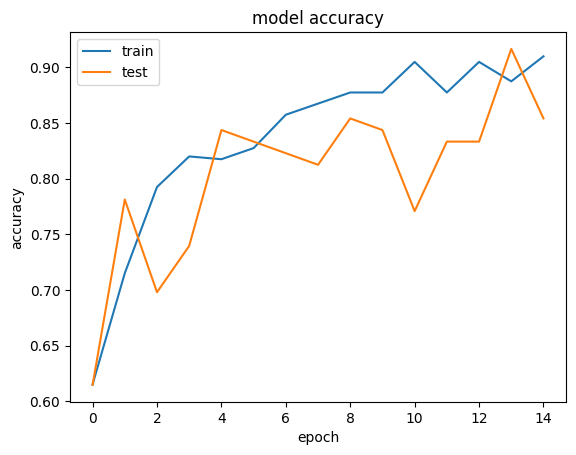

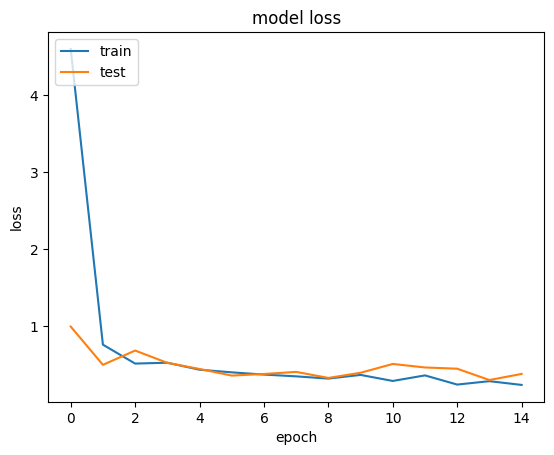

In [6]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

EXERCICE

QST N°3 :Quel est l’effet sur les performances en classfication?
La normalisation améliore la stabilité de l’entraînement mais n’augmente pas la diversité des données. L’utilisation de la data augmentation permet de générer plusieurs variations des images, ce qui réduit l’overfitting et améliore les performances de classification sur les données de validation et les nouvelles données.

In [7]:
train_datagen = ImageDataGenerator(rescale = 1. / 255)
test_datagen = ImageDataGenerator(rescale = 1. / 255)
train_generator = train_datagen.flow_from_directory(train_data_dir,target_size =(img_width, img_height),
batch_size = batch_size, class_mode ='categorical')
validation_generator = test_datagen.flow_from_directory(validation_data_dir,target_size =(img_width, img_height),batch_size = batch_size, class_mode ='categorical')

Found 400 images belonging to 2 classes.
Found 100 images belonging to 2 classes.


In [15]:
model = Sequential()
model.add(Conv2D(num_filters, (3,3), input_shape = input_shape))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size = (2, 2)))
model.add(Flatten())
model.add(Dense(24))
model.add(Dense(2))
model.add(Activation('sigmoid'))
print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 222, 222, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 111, 111, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 98568)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 24)             │     2,365,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 2)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,365,930 (9.03 MB)

 Trainable params: 2,365,930 (9.03 MB)

 Non-trainable params: 0 (0.00 B)

None


In [16]:
model.compile(loss ='binary_crossentropy',
optimizer ='rmsprop',

metrics =['accuracy'])
history=model.fit(train_generator,
steps_per_epoch = nb_train_samples // batch_size,
epochs = epochs, validation_data = validation_generator,
validation_steps = nb_validation_samples // batch_size)

Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 252ms/step - accuracy: 0.5825 - loss: 29.0110 - val_accuracy: 0.6458 - val_loss: 6.1497
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 205ms/step - accuracy: 0.6575 - loss: 8.2253 - val_accuracy: 0.6562 - val_loss: 9.5184
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 274ms/step - accuracy: 0.7575 - loss: 3.4328 - val_accuracy: 0.6042 - val_loss: 6.2983
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 203ms/step - accuracy: 0.7625 - loss: 1.5584 - val_accuracy: 0.7604 - val_loss: 0.6485
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 240ms/step - accuracy: 0.7925 - loss: 0.7116 - val_accuracy: 0.8229 - val_loss: 0.4514
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 220ms/step - accuracy: 0.8025 - loss: 0.5647 - val_accuracy: 0.7292 - val_loss: 0.5383
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 202ms/step - accuracy: 0.8200 - loss: 0.4076 - val_accuracy: 0.7812 - val_loss: 0.6346
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 278ms/step - accuracy: 0.8225 - loss: 0.4925 - val_accuracy: 0

QST N°4:


In [8]:
train_datagen = ImageDataGenerator(
rescale = 1. / 255,
shear_range = 0.2,
zoom_range = 0.2,
horizontal_flip = True)
test_datagen = ImageDataGenerator(rescale = 1. / 255)
train_generator = train_datagen.flow_from_directory(train_data_dir,target_size =(img_width, img_height),
batch_size = batch_size, class_mode ='categorical')
validation_generator = test_datagen.flow_from_directory(validation_data_dir,target_size =(img_width, img_height),batch_size = batch_size, class_mode ='categorical')

Found 400 images belonging to 2 classes.
Found 100 images belonging to 2 classes.


In [12]:
# Création du modèle CNN
model = Sequential()

# Couche d'entrée : définit la taille des images en entrée
model.add(Input(shape=input_shape))

## Bloc convolutionnel 1
# Conv2D applique 32 filtres de taille 3x3 pour extraire les caractéristiques de l'image
# padding='same' permet de garder la même taille de l'image après la convolution
model.add(Conv2D(32, (3,3), activation='relu', padding='same'))

# MaxPooling réduit la taille de l'image pour diminuer le nombre de calculs
model.add(MaxPooling2D(2,2))

##Bloc convolutionnel 2
# Extraction de caractéristiques plus complexes
# padding='same' conserve la dimension spatiale de l'image
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D(2,2))

## Bloc convolutionnel 3
# Détection de caractéristiques plus avancées
# padding='same' évite la réduction de taille due à la convolution
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D(2,2))

#  Passage vers les couches fully connected
# Flatten transforme les matrices en vecteur
model.add(Flatten())

# Couche dense pour apprendre les relations entre les caractéristiques
model.add(Dense(128, activation='relu'))

# Dropout désactive 50% des neurones pendant l'entraînement pour éviter l'overfitting
model.add(Dropout(0.5))

## Couche de sortie
# 2 neurones car on a 2 classes
# softmax donne la probabilité pour chaque classe
model.add(Dense(2, activation='softmax'))

## Compilation
# rmsprop : algorithme d'optimisation
# binary_crossentropy : fonction de perte
# accuracy : métrique de performance
model.compile(optimizer='rmsprop', loss ='binary_crossentropy', metrics=['accuracy'])

# Affichage du résumé du modèle
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,690 (49.36 MB)

 Trainable params: 12,938,690 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Entraînement
history=model.fit(train_generator,
steps_per_epoch = nb_train_samples // batch_size,
epochs = epochs, validation_data = validation_generator,
validation_steps = nb_validation_samples // batch_size)

Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 275ms/step - accuracy: 0.5575 - loss: 1.0962 - val_accuracy: 0.6250 - val_loss: 0.5416
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 265ms/step - accuracy: 0.6575 - loss: 0.7066 - val_accuracy: 0.6354 - val_loss: 0.5224
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 242ms/step - accuracy: 0.7650 - loss: 0.5812 - val_accuracy: 0.8854 - val_loss: 0.3556
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 227ms/step - accuracy: 0.8200 - loss: 0.4141 - val_accuracy: 0.8229 - val_loss: 0.3504
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 288ms/step - accuracy: 0.8650 - loss: 0.3586 - val_accuracy: 0.8854 - val_loss: 0.3392
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 256ms/step - accuracy: 0.8800 - loss: 0.3552 - val_accuracy: 0.8438 - val_loss: 0.3454
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 251ms/step - accuracy: 0.8250 - loss: 0.3857 - val_accuracy: 0.9062 - val_loss: 0.3084
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 226ms/step - accuracy: 0.8750 - loss: 0.3203 - val_accuracy: 0

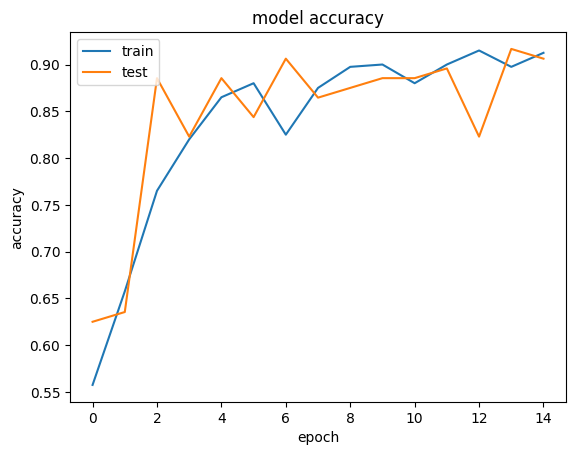

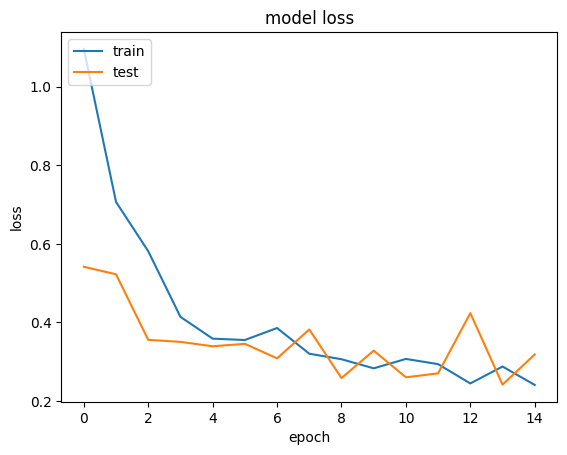

In [14]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

La nouvelle CNN utilise trois couches convolutionnelles suivies de MaxPooling, puis une couche Dense avec Dropout pour réduire l’overfitting, et une couche de sortie sigmoid pour la classification binaire. Comparée au CNN initial, elle permet d’extraire des caractéristiques plus complexes, réduit le surapprentissage et améliore la généralisation. Les performances attendues sont une accuracy de validation plus élevée .

QST N°5:


Pour classifier en fonction de la luminance, il faut convertir les images en niveaux de gris en utilisant color_mode='grayscale' dans les générateurs de données et modifier la dimension d’entrée du modèle en (img_width, img_height, 1) afin de travailler avec un seul canal correspondant à l’intensité lumineuse.

In [18]:
os.chdir("/content/drive/MyDrive/v_data")
img_width, img_height = 224, 224
train_data_dir = 'v_data/train'
validation_data_dir = 'v_data/test'
nb_train_samples = 400
nb_validation_samples = 100
epochs = 15
batch_size = 16
num_filters = 8
filter_size = 3
if K.image_data_format() == 'channels_first':input_shape = (1, img_width, img_height)
else:input_shape = (img_width, img_height, 1)

In [19]:

train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
     # images en niveaux de gris
    color_mode='grayscale'
)

validation_generator = test_datagen.flow_from_directory(
    validation_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    color_mode='grayscale'
)

Found 400 images belonging to 2 classes.
Found 100 images belonging to 2 classes.


Conclusion : Dans ce TP, nous avons utilisé un réseau de neurones convolutionnel (CNN) pour la classification d’images. Nous avons amélioré l’architecture du modèle en ajoutant plusieurs couches convolutionnelles, du pooling et du Dropout pour réduire l’overfitting. Nous avons aussi appliqué la normalisation, la data augmentation et la conversion en niveaux de gris. Ces techniques permettent d’améliorer les performances et la généralisation du modèle de classification.
